In [1]:
from sklearn.datasets import fetch_california_housing

import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline 

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score 

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [2]:
housing = fetch_california_housing(as_frame=True)
df_original = housing.frame
df = df_original.copy()

## EDA

### MedInc
MedInc has 690 entries above 8, 2 stdevs above mean, but it's progressive so doesn't seem crazy

### HouseAge
HouseAge looks fine

### AveRooms
AveRooms has 2 potential outliers of 141 and 132, even the 60 rooms are pretty afar off from the mean+std, but it's progressive

### AveBedrms
AveBedrms has the same 2 outliers from AveRoom, index1914, index1979

### Population
Population has 2 outliers signficantly out, Index9880, Index15360

### AveOccup
AveOccup has 4 outliers, Index3364, 13034, 16669, 19006
AveOccup is highly right-skewed, with a median of 2.8 and mean of 3, std of 10, but max of 1243
the 4 index (all >100) seems highly unplausible, therefore treated as outliers and removed 

In [3]:
outliers_index = [
    1914,
    1979,
    9880,
    15360,
    3364,
    13034,
    16669,
    19006
]

# print(df.loc[outliers_index])

# print(df['AveOccup'].describe())
# print(df['AveOccup'].sort_values(ascending=False).head(20))

In [42]:
#filtering down those with AveOccup of more than 100 per resident, based on the empericial and anectodal logic, a residence with more than 100 ocuppants is highly unplausible
df = df[df['AveOccup'] <= 100]

In [5]:
y = df['MedHouseVal']
X = df.drop(['MedHouseVal'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state=42,
                                                   )

preprocessor = Pipeline([
    ('preprocess', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [6]:
#linearRegression baseline model

model_LR = Pipeline([
    ("preprecessor", preprocessor),
    ("linear_reg", LinearRegression())
])

model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)

model_LR_MAE = mean_absolute_error(y_test, y_pred)
model_LR_MSE = mean_squared_error(y_test, y_pred)
model_LR_RMSE = np.sqrt(model_LR_MSE)
model_LR_r2 = r2_score(y_test, y_pred)

print(model_LR_MAE)
print(model_LR_RMSE)
print(model_LR_r2)

0.5130730108879092
0.7220715230668358
0.6057158459716574


In [7]:
#RandomForestRegressor baseline model

model_RFR = Pipeline([
    ('preprocessor', preprocessor),
    ('randomforest', RandomForestRegressor(n_estimators=100,
                                           random_state=42
    ))
])

model_RFR.fit(X_train, y_train)
y_pred = model_RFR.predict(X_test)

model_RFR_MAE = mean_absolute_error(y_test, y_pred)
model_RFR_MSE = mean_squared_error(y_test, y_pred)
model_RFR_RMSE = np.sqrt(model_RFR_MSE)
model_RFR_r2 = r2_score(y_test, y_pred)

print(model_RFR_MAE)
print(model_RFR_RMSE)
print(model_RFR_r2)

print("Training R2:", model_RFR.score(X_train, y_train))
print("Test R2:", model_RFR.score(X_test, y_test))

0.3324132445494188
0.5209504572742295
0.7947695793855807
Training R2: 0.9737973193938616
Test R2: 0.7947695793855807


In [8]:
#DecisionTreeRegressor baseline model

model_DTR = Pipeline([
    ('preprocessor', preprocessor),
    ('decisiontree', DecisionTreeRegressor(random_state=42))
])

model_DTR.fit(X_train, y_train)
y_pred = model_DTR.predict(X_test)

model_DTR_MAE = mean_absolute_error(y_test, y_pred)
model_DTR_MSE = mean_squared_error(y_test, y_pred)
model_DTR_RMSE = np.sqrt(model_DTR_MSE)
model_DTR_r2 = r2_score(y_test, y_pred)

print(model_DTR_MAE)
print(model_DTR_RMSE)
print(model_DTR_r2)

print("Training R2: ", model_DTR.score(X_train, y_train))
print("Test R2: ", model_DTR.score(X_test, y_test))

0.453369878875969
0.716012695590486
0.6123048806722347
Training R2:  1.0
Test R2:  0.6123048806722347


In [9]:
#MLPRegressor baseline model

model_MLP = Pipeline([
    ('preprocessing', preprocessor),
    ('MLP', MLPRegressor(random_state=42))
])

model_MLP.fit(X_train, y_train)
y_pred = model_MLP.predict(X_test)

model_MLP_MAE = mean_absolute_error(y_test, y_pred)
model_MLP_MSE = mean_squared_error(y_test, y_pred)
model_MLP_RMSE = np.sqrt(model_MLP_MSE)
model_MLP_r2 = r2_score(y_test, y_pred)

print(model_MLP_MAE)
print(model_MLP_RMSE)
print(model_MLP_r2)

print("Training R2: ", model_MLP.score(X_train, y_train))
print("Test R2: ", model_MLP.score(X_test, y_test))

0.3643254893407912
0.543640341457103
0.7765027204320781
Training R2:  0.8091784901927993
Test R2:  0.7765027204320781


C:\Users\Russell\anaconda3\envs\sp500\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
#GradientBoostingRegressor basleine model

model_GBR = Pipeline([
    ("preprocessor", preprocessor),
    ("gradientBR", GradientBoostingRegressor(random_state=42))
])

model_GBR.fit(X_train, y_train)
y_pred = model_GBR.predict(X_test)

model_GBR_MAE = mean_absolute_error(y_test, y_pred)
model_GBR_MSE = mean_squared_error(y_test, y_pred)
model_GBR_RMSE = np.sqrt(model_GBR_MSE)
model_GBR_r2 = r2_score(y_test, y_pred)

print(model_GBR_MAE)
print(model_GBR_RMSE)
print(model_GBR_r2)

print("Training R2: ", model_GBR.score(X_train, y_train))
print("Test R2: ", model_GBR.score(X_test, y_test))

0.37531599977127644
0.5472369490012192
0.7735357184269718
Training R2:  0.8081429241877414
Test R2:  0.7735357184269718


## Baseline Models Analysis

LinearRegression provides a baseline, with R2 of 0.606

DecisionTree only slightly better than LinearRegression, with a R2 of 0.612, and significantly overfitting with a R2 of 1 on training

RandomForest is the bestperforming baseline, R2 of 0.795, but with a big gap between training R2 of 0.974 and test R2, indicting overfitting

MLPRegressor and Gradient Boosting performed similary, with tes R2 of 0.777 and 0.774, with relatively smaller training-test gaps

In [13]:
#RandomForest tuning

n_estismators= [10,25,50,100]
max_depth = [5,10,20,50] 
min_samples_split=[2,5,10,20]
min_samples_leaf=[1,5,10,20]

params = {
    "randomforest__n_estimators": n_estismators,
    "randomforest__max_depth": max_depth,
    "randomforest__min_samples_split": min_samples_split,
    "randomforest__min_samples_leaf": min_samples_leaf
}

model_RFR_opt = RandomizedSearchCV(
    model_RFR,
    param_distributions=params,
    scoring="r2",
    random_state=42,
    cv=5,
    n_iter=30,
    n_jobs=-1,
    verbose=2
)

model_RFR_opt.fit(X_train, y_train)

print("done")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
done


In [23]:
#Randomforest post tuning results

print(model_RFR_opt.best_params_)
print(model_RFR_opt.best_score_)

y_pred = model_RFR_opt.predict(X_test)

model_RFR_opt_MAE = mean_absolute_error(y_test, y_pred)
model_RFR_opt_MSE = mean_squared_error(y_test, y_pred)
model_RFR_opt_RMSE = np.sqrt(model_RFR_opt_MSE)
model_RFR_opt_r2 = r2_score(y_test, y_pred) 

print(model_RFR_opt_MAE)
print(model_RFR_opt_RMSE)
print(model_RFR_opt_r2)

{'randomforest__n_estimators': 100, 'randomforest__min_samples_split': 5, 'randomforest__min_samples_leaf': 1, 'randomforest__max_depth': 50}
0.8079411343147054
0.3331467822515468
0.521428105848447
0.7943930638980047


In [25]:
#MLP tuning

hidden_layer_sizes = [(50,), (100,), (100,50), (100,100)]
alpha = [0.0001, 0.001, 0.01, 0.1]
learning_rate_init = [0.0001, 0.001, 0.01]
max_iter = [200,500,1000] 

params = {
    "MLP__hidden_layer_sizes": hidden_layer_sizes,
    "MLP__alpha": alpha,
    "MLP__learning_rate_init": learning_rate_init,
    "MLP__max_iter": max_iter
}

model_MLP_opt = RandomizedSearchCV(
    model_MLP,
    param_distributions=params,
    n_iter=10,
    scoring="r2",
    cv=3,
    verbose=2
)

model_MLP_opt.fit(X_train, y_train)

print("done")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END MLP__alpha=0.01, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.0001, MLP__max_iter=1000; total time= 1.1min
[CV] END MLP__alpha=0.01, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.0001, MLP__max_iter=1000; total time= 2.0min
[CV] END MLP__alpha=0.01, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.0001, MLP__max_iter=1000; total time= 1.5min
[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.01, MLP__max_iter=500; total time=   9.2s
[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.01, MLP__max_iter=500; total time=   9.2s
[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.01, MLP__max_iter=500; total time=  10.0s
[CV] END MLP__alpha=0.1, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.001, MLP__max_iter=1000; total time=  15.9s
[CV] END MLP_

C:\Users\Russell\anaconda3\envs\sp500\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(100,), MLP__learning_rate_init=0.0001, MLP__max_iter=200; total time=  15.5s


C:\Users\Russell\anaconda3\envs\sp500\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(100,), MLP__learning_rate_init=0.0001, MLP__max_iter=200; total time=  15.9s


C:\Users\Russell\anaconda3\envs\sp500\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(100,), MLP__learning_rate_init=0.0001, MLP__max_iter=200; total time=  15.3s


C:\Users\Russell\anaconda3\envs\sp500\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END MLP__alpha=0.01, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.0001, MLP__max_iter=200; total time=  33.4s


C:\Users\Russell\anaconda3\envs\sp500\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END MLP__alpha=0.01, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.0001, MLP__max_iter=200; total time=  33.6s


C:\Users\Russell\anaconda3\envs\sp500\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END MLP__alpha=0.01, MLP__hidden_layer_sizes=(100, 100), MLP__learning_rate_init=0.0001, MLP__max_iter=200; total time=  33.2s
[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(50,), MLP__learning_rate_init=0.001, MLP__max_iter=500; total time=  10.6s
[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(50,), MLP__learning_rate_init=0.001, MLP__max_iter=500; total time=  15.7s
[CV] END MLP__alpha=0.0001, MLP__hidden_layer_sizes=(50,), MLP__learning_rate_init=0.001, MLP__max_iter=500; total time=  12.7s
done


In [37]:
#tuned MLP results

print(model_MLP_opt.best_params_)
print(model_MLP_opt.best_score_)

y_pred = model_MLP_opt.predict(X_test)

model_MLP_opt_MAE = mean_absolute_error(y_test, y_pred)
model_MLP_opt_MSE = mean_squared_error(y_test, y_pred)
model_MLP_opt_RMSE = np.sqrt(model_MLP_opt_MSE)
model_MLP_opt_r2 = r2_score(y_test, y_pred)

print(model_MLP_opt_MAE)
print(model_MLP_opt_RMSE)
print(model_MLP_opt_r2)

print("Training R2: ", model_MLP_opt.score(X_train, y_train))
print("Test R2: ", model_MLP_opt.score(X_test, y_test))

{'MLP__max_iter': 1000, 'MLP__learning_rate_init': 0.001, 'MLP__hidden_layer_sizes': (100, 100), 'MLP__alpha': 0.1}
0.7948512107827393
0.3536732569047424
0.5263620804689574
0.7904835737252278
Training R2:  0.8291962279848262
Test R2:  0.7904835737252278


In [36]:
#Gradient Boosting Tuning

n_estimators = [50, 100, 200, 300, 500]
learning_rate = [0.01, 0.03, 0.05, 0.1, 0.2]
max_depth = [2,3,4,5,7]
min_samples_split = [2,5,10,20]
min_samples_leaf = [1,2,5,10]

params = {
    "gradientBR__n_estimators": n_estimators,
    "gradientBR__learning_rate": learning_rate,
    "gradientBR__max_depth": max_depth,
    "gradientBR__min_samples_split": min_samples_split,
    "gradientBR__min_samples_leaf": min_samples_leaf 
}

model_GBR_opt = RandomizedSearchCV(
    model_GBR,
    param_distributions=params,
    n_iter=10,
    scoring="r2",
    cv=5, 
    verbose=2, 
    random_state=42
)

model_GBR_opt.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END gradientBR__learning_rate=0.05, gradientBR__max_depth=7, gradientBR__min_samples_leaf=1, gradientBR__min_samples_split=5, gradientBR__n_estimators=100; total time=  10.9s
[CV] END gradientBR__learning_rate=0.05, gradientBR__max_depth=7, gradientBR__min_samples_leaf=1, gradientBR__min_samples_split=5, gradientBR__n_estimators=100; total time=  10.2s
[CV] END gradientBR__learning_rate=0.05, gradientBR__max_depth=7, gradientBR__min_samples_leaf=1, gradientBR__min_samples_split=5, gradientBR__n_estimators=100; total time=  10.5s
[CV] END gradientBR__learning_rate=0.05, gradientBR__max_depth=7, gradientBR__min_samples_leaf=1, gradientBR__min_samples_split=5, gradientBR__n_estimators=100; total time=  10.8s
[CV] END gradientBR__learning_rate=0.05, gradientBR__max_depth=7, gradientBR__min_samples_leaf=1, gradientBR__min_samples_split=5, gradientBR__n_estimators=100; total time=  10.5s
[CV] END gradientBR__learning_rate=0.1,

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'gradientBR__learning_rate': [0.01, 0.03, ...], 'gradientBR__max_depth': [2, 3, ...], 'gradientBR__min_samples_leaf': [1, 2, ...], 'gradientBR__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estima

In [41]:
#Gradient Tuning optimized model

print(model_GBR_opt.best_params_)
print(model_GBR_opt.best_score_)

y_pred = model_GBR_opt.predict(X_test)
model_GBR_opt_MAE = mean_absolute_error(y_test, y_pred)
model_GBR_opt_MSE = mean_squared_error(y_test, y_pred)
model_GBR_opt_RMSE = np.sqrt(model_GBR_opt_MSE)
model_GBR_opt_r2 = r2_score(y_test, y_pred)

print(model_GBR_opt_MAE)
print(model_GBR_opt_RMSE)
print(model_GBR_opt_r2)

print("Training r2: ", model_GBR_opt.score(X_train, y_train))
print("testing r2: ", model_GBR_opt.score(X_test, y_test))

{'gradientBR__n_estimators': 500, 'gradientBR__min_samples_split': 20, 'gradientBR__min_samples_leaf': 1, 'gradientBR__max_depth': 5, 'gradientBR__learning_rate': 0.1}
0.8411644466345527
0.3043320058075722
0.47133001701739846
0.8320039439681006
Training r2:  0.9356358846890231
testing r2:  0.8320039439681006


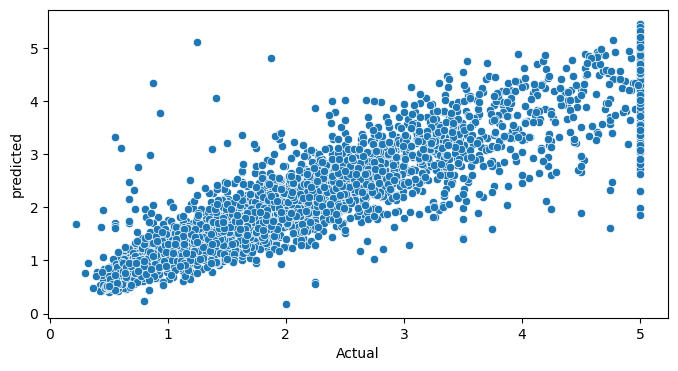

In [52]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(8,4))
sns.scatterplot(x=y_test, y=y_pred, ax=ax1)

ax1.set_xlabel("Actual")
ax1.set_ylabel("predicted")
plt.show()

##After tuning analysis

For randomforest, the tuning didn't improve the model's r2

For MLP, all the metrics improved, with R2 increasing to 0.79 from 0.777

For GBR, all the metrics improved, with R2 increasing to 0.83 on the test dataset, GBR wins